In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [15]:
load_dotenv()
model = ChatOpenAI()

In [16]:
class BlogState(TypedDict):
    title: str
    outline: str
    content : str

In [22]:
def create_outline(state:BlogState)-> BlogState:
    #fetch title
    title = state['title']
    
    #call LLM to generate outline
    prompt = f'Generate a detailed blog outline for a blog on the topic - {title}'
    answer = model.invoke(prompt).content
    
    #update state
    state['outline'] = answer
    
    return state

In [23]:
def create_blog(state:BlogState)-> BlogState:
    #fetch title
    title = state['title']
    outline = state['outline']
    
    #call LLM to generate outline
    prompt = f'Write a detailed blog on the topic - {title} using the given outline - {outline}'
    answer = model.invoke(prompt).content
    
    #update state
    state['content'] = answer
    
    return state

In [24]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('outline',create_outline)
graph.add_node('blog',create_blog)

#edges
graph.add_edge(START,'outline')
graph.add_edge('outline','blog')
graph.add_edge('blog',END)

#compile
workflow = graph.compile()


In [27]:
input_state=  {
    'title': 'My first love'
}
output_state = workflow.invoke(input_state)

print(output_state['outline'])
print(output_state['content'])

I. Introduction
    A. Definition of love
    B. Importance of first love
    C. Personal experience with first love

II. Meeting my first love
    A. How we met
    B. Initial feelings and emotions
    C. Getting to know each other

III. Falling in love 
    A. Signs of falling in love
    B. Shared experiences and memories
    C. How we supported each other

IV. Challenges in the relationship
    A. Miscommunications and misunderstandings
    B. External factors affecting the relationship
    C. How we overcame challenges

V. The end of the relationship
    A. Reasons for the breakup
    B. Emotional impact of the breakup
    C. Closure and moving on

VI. Lessons learned from first love
    A. Self-discovery and personal growth
    B. Understanding of love and relationships
    C. How first love shaped future relationships

VII. Conclusion
    A. Reflection on first love experience
    B. Gratitude for the lessons learned
    C. Hope for future love and relationships
I. Introduction


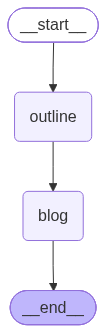

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())